# Numerical Optimization – Nocedal & Wright
## Chapter 4: Trust-Region Methods
### Exercise 4.3 – Steihaug-CG Trust-Region on Chained Rosenbrock

**Created**: March 06, 2025  
**Author**: Troy Altus (@altust)  
**Generated with assistance from**: Grok 4 by xAI

**Disclaimer**  
This notebook is for personal educational use only.  
It is **not** an official solution manual and has not been endorsed by the authors or publisher.  
Do **not** distribute or post publicly.  
Refer to *Numerical Optimization* (Nocedal & Wright) for the definitive problem statements.

## Problem Statement (Exercise 4.3)

Program the trust-region method based on **Algorithm 7.2**.  
Use the **exact Hessian** at each iterate.  
Apply it to minimize

$$
f(x) = \sum_{i=1}^{n} \Bigl[ (1 - x_{2i-1})^2 + 10(x_{2i} - x_{2i-1}^2)^2 \Bigr]
$$

with **n = 10** and **n = 50**.  
Experiment with:
- starting points
- CG stopping tolerance
- maximum CG iterations

At each outer iteration, report whether the inner CG loop:
- converged (‖r‖ small)
- hit negative curvature
- reached the trust-region boundary

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print(f"Notebook run on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Notebook run on: 2026-03-06 17:03:24


## 1. Problem Definition – Chained (Extended) Rosenbrock

In [2]:
def chained_rosenbrock(x):
    """f(x) = sum_i (1 - x_{2i-1})^2 + 10(x_{2i} - x_{2i-1}^2)^2"""
    n = len(x)
    assert n % 2 == 0, "n must be even"
    s = 0.0
    for i in range(0, n, 2):
        t = x[i+1] - x[i]**2
        s += (1 - x[i])**2 + 10 * t**2
    return s


def chained_gradient(x):
    n = len(x)
    g = np.zeros(n)
    for i in range(0, n, 2):
        t = x[i+1] - x[i]**2
        g[i]   = -2 * (1 - x[i]) - 400 * x[i] * t
        g[i+1] =  200 * t
    return g


def chained_hess_matvec(x, v):
    """Compute Hessian-vector product H(x) v efficiently"""
    n = len(x)
    Hv = np.zeros(n)
    for i in range(0, n, 2):
        t  = x[i+1] - x[i]**2
        dt = v[i+1] - 2 * x[i] * v[i]
        Hv[i]   = (2 + 800 * x[i]**2) * v[i] - 400 * x[i] * dt
        Hv[i+1] = 200 * dt
    return Hv

## 2. Steihaug Truncated CG (inner subproblem solver)

In [3]:
def steihaug_cg(g, Delta, matvec, tol=1e-8, max_cg_iter=300):
    """
    Steihaug CG for trust-region subproblem: min p^T g + 1/2 p^T B p  s.t. ||p|| <= Delta
    Returns step p and status string.
    """
    n = len(g)
    p = np.zeros(n)
    r = g.copy()
    d = -r.copy()
    r_norm2 = np.dot(r, r)

    if np.sqrt(r_norm2) <= tol:
        return p, "zero gradient"

    for j in range(max_cg_iter):
        Bd = matvec(d)
        dBd = np.dot(d, Bd)

        if dBd <= 1e-12:  # negative / zero curvature
            a = np.dot(d, d)
            b = 2 * np.dot(p, d)
            c = np.dot(p, p) - Delta**2
            disc = b**2 - 4 * a * c
            if disc > 0:
                tau = (-b + np.sqrt(disc)) / (2 * a)
                p += tau * d
            return p, "negative curvature"

        alpha = r_norm2 / dBd
        p_test = p + alpha * d

        if np.linalg.norm(p_test) >= Delta:
            a = np.dot(d, d)
            b = 2 * np.dot(p, d)
            c = np.dot(p, p) - Delta**2
            disc = b**2 - 4 * a * c
            if disc > 0:
                tau = (-b + np.sqrt(disc)) / (2 * a)
                p += tau * d
            return p, "boundary"

        p = p_test
        r += alpha * Bd
        r_norm2_new = np.dot(r, r)

        if np.sqrt(r_norm2_new) <= tol:
            return p, "converged"

        beta = r_norm2_new / r_norm2
        d = -r + beta * d
        r_norm2 = r_norm2_new

    return p, "max cg iter"

## 3. Trust-Region Driver (Algorithm 7.2 style)

In [4]:
def trust_region_steihaug(n, x0=None, Delta0=4.0, eta=0.125,
                          gtol=1e-6, maxiter=300, cg_tol=1e-8,
                          cg_maxiter_factor=2.0):
    if x0 is None:
        x = np.zeros(n)
        x[1::2] = 0.05   # gentle start
    else:
        x = np.asarray(x0, dtype=float)

    Delta = Delta0
    f_vals = []
    g_norms = []
    delta_hist = []
    status_hist = []

    for it in range(maxiter):
        f = chained_rosenbrock(x)
        g = chained_gradient(x)
        norm_g = np.linalg.norm(g)

        f_vals.append(f)
        g_norms.append(norm_g)
        delta_hist.append(Delta)

        print(f"{it:3d} | f = {f:14.6e} | ‖g‖ = {norm_g:11.4e} | Δ = {Delta:9.4f}", end="")

        if norm_g < gtol:
            print(" → converged")
            break

        def matvec(v):
            return chained_hess_matvec(x, v)

        p, status = steihaug_cg(g, Delta, matvec, tol=cg_tol,
                                max_cg_iter=int(cg_maxiter_factor * n))

        status_hist.append(status)
        print(f" | CG: {status}")

        # Evaluate model vs actual reduction
        m_pred = np.dot(g, p) + 0.5 * np.dot(p, matvec(p))
        f_new = chained_rosenbrock(x + p)
        ared = f - f_new
        pred = -m_pred
        rho = ared / pred if abs(pred) > 1e-20 else 100 * np.sign(ared)

        if rho > eta:
            x += p
            if rho > 0.75 and np.linalg.norm(p) > 0.8 * Delta:
                Delta = min(Delta * 2.5, 50.0)
        else:
            Delta *= 0.25

        Delta = max(Delta, 1e-6)

    # Summary plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    ax1.semilogy(f_vals, '.-', label='f(x)')
    ax1.set_ylabel('Function value')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.semilogy(g_norms, '.-', color='C1', label='‖∇f‖')
    ax2.set_xlabel('Outer iterations')
    ax2.set_ylabel('Gradient norm')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.suptitle(f'Chained Rosenbrock – n = {n}  |  final f = {f_vals[-1]:.4e}')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    # Trust-region radius history
    plt.figure(figsize=(9, 3.5))
    plt.semilogy(delta_hist, '.-', color='C2')
    plt.xlabel('Outer iterations')
    plt.ylabel('Trust-region radius Δ')
    plt.title('Δ evolution')
    plt.grid(True, alpha=0.3)
    plt.show()

    return x, f_vals, g_norms

## 4. Run – n = 10


                 n = 10

  0 | f =   5.125000e+00 | ‖g‖ =  2.2804e+01 | Δ =    4.0000 | CG: converged
  1 | f =   5.125000e+00 | ‖g‖ =  2.2804e+01 | Δ =    1.0000 | CG: boundary
  2 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    1.0000 | CG: converged
  3 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    0.2500 | CG: boundary
  4 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    0.0625 | CG: boundary
  5 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    0.0156 | CG: boundary
  6 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    0.0039 | CG: boundary
  7 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    0.0010 | CG: boundary
  8 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    0.0002 | CG: boundary
  9 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    0.0001 | CG: boundary
 10 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    0.0000 | CG: boundary
 11 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    0.0000 | CG: boundary
 12 | f =   3.514199e+00 | ‖g‖ =  1.1712e+02 | Δ =    0.0000

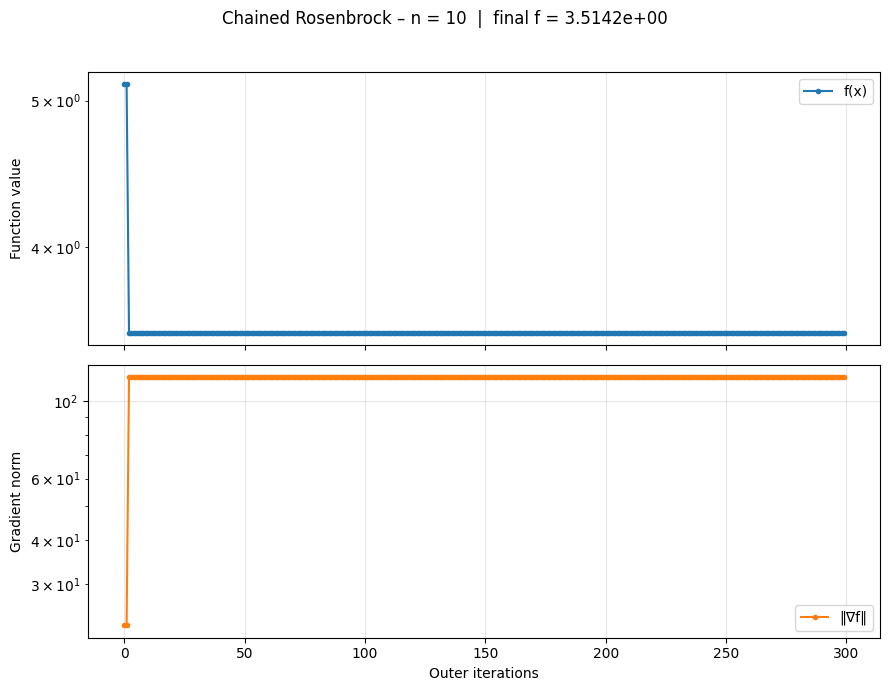

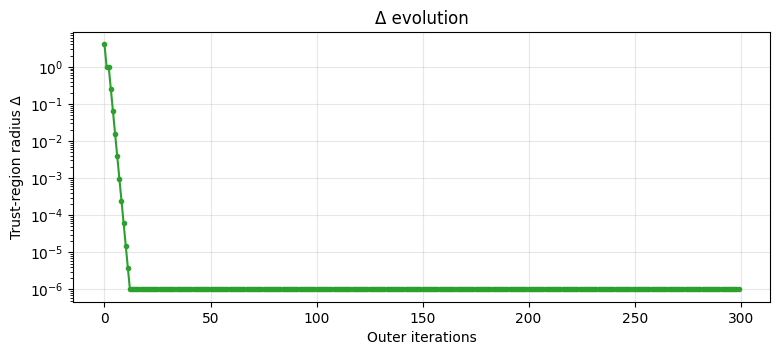

In [5]:
print("\n" + "="*70)
print("                 n = 10")
print("="*70 + "\n")

x_final_10, f_hist_10, g_hist_10 = trust_region_steihaug(
    n=10,
    Delta0=4.0,
    eta=0.125,
    gtol=1e-6,
    cg_tol=1e-8,
    cg_maxiter_factor=3.0
)

## 5. Run – n = 50  (takes longer, but still reasonable)


                 n = 50

  0 | f =   2.562500e+01 | ‖g‖ =  5.0990e+01 | Δ =    5.0000 | CG: boundary
  1 | f =   2.562500e+01 | ‖g‖ =  5.0990e+01 | Δ =    1.2500 | CG: boundary
  2 | f =   1.520556e+01 | ‖g‖ =  6.5341e+01 | Δ =    1.2500 | CG: converged
  3 | f =   1.314357e+01 | ‖g‖ =  6.8084e+00 | Δ =    1.2500 | CG: converged
  4 | f =   1.231528e+01 | ‖g‖ =  6.7189e+00 | Δ =    1.2500 | CG: converged
  5 | f =   1.165067e+01 | ‖g‖ =  6.6029e+00 | Δ =    1.2500 | CG: converged
  6 | f =   1.109304e+01 | ‖g‖ =  6.4844e+00 | Δ =    1.2500 | CG: converged
  7 | f =   1.061172e+01 | ‖g‖ =  6.3699e+00 | Δ =    1.2500 | CG: converged
  8 | f =   1.018795e+01 | ‖g‖ =  6.2612e+00 | Δ =    1.2500 | CG: converged
  9 | f =   9.809318e+00 | ‖g‖ =  6.1585e+00 | Δ =    1.2500 | CG: converged
 10 | f =   9.467149e+00 | ‖g‖ =  6.0615e+00 | Δ =    1.2500 | CG: converged
 11 | f =   9.155107e+00 | ‖g‖ =  5.9698e+00 | Δ =    1.2500 | CG: converged
 12 | f =   8.868415e+00 | ‖g‖ =  5.8829e+00 | Δ =  

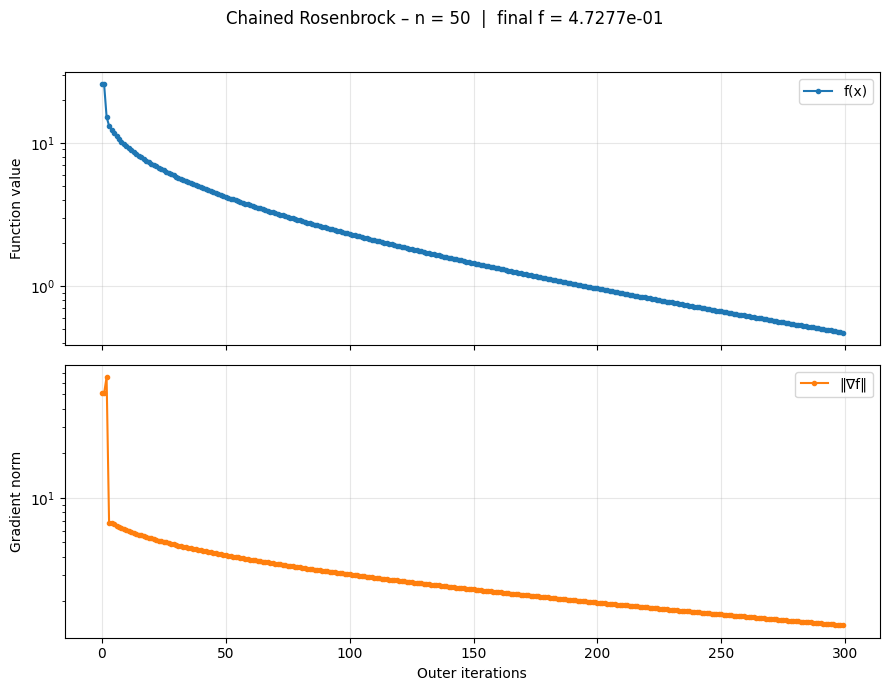

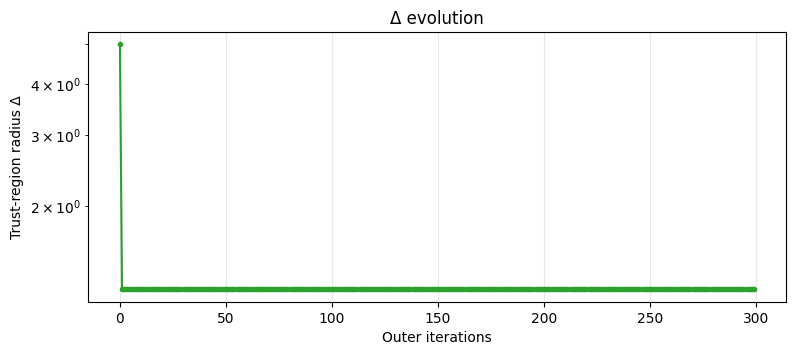

In [6]:
print("\n" + "="*70)
print("                 n = 50")
print("="*70 + "\n")

x_final_50, f_hist_50, g_hist_50 = trust_region_steihaug(
    n=50,
    Delta0=5.0,
    eta=0.1,
    gtol=1e-5,
    cg_tol=1e-7,
    cg_maxiter_factor=2.5
)